# Non-linear regression
In this notebook we will investigating working with data that we cannot fit a line/plane/hyper-plane to.
What are the approaches of dealing with such a data.

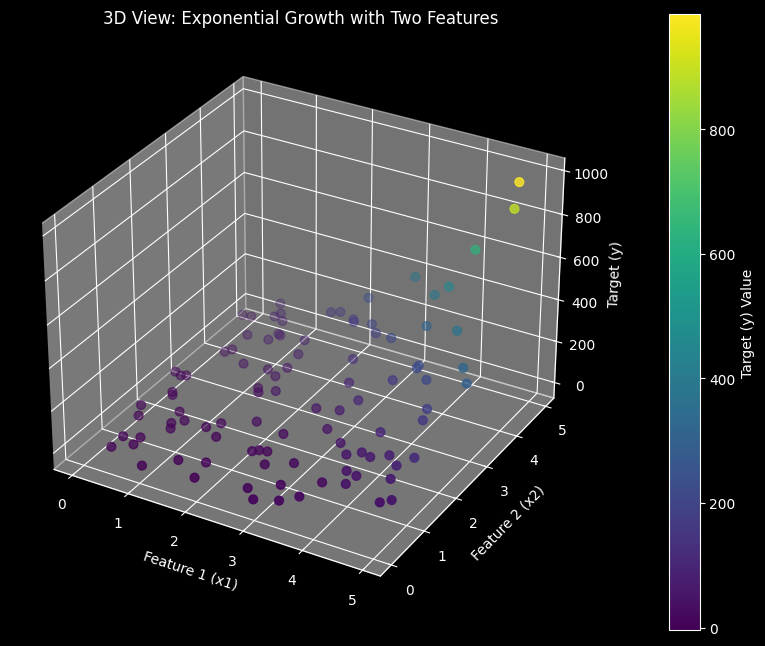

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from linreg.linreg import LinearRegression
from scipy.optimize import curve_fit

np.random.seed(42)

x1 = np.random.uniform(0, 5, 100)
x2 = np.random.uniform(0, 5, 100)

# 2. Define the exponential growth relationship
# Formula: y = A * exp(B*x1 + C*x2)
# We will set A=2.0, B=0.4, C=0.5
y_true = 2.0 * np.exp(0.6 * x1 + 0.7 * x2)

noise = np.random.normal(0, 5, 100)
y = y_true + noise

# 4. Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x1, x2, y, c=y, cmap='viridis', marker='o', s=40)

ax.set_xlabel('Feature 1 (x1)')
ax.set_ylabel('Feature 2 (x2)')
ax.set_zlabel('Target (y)')
ax.set_title('3D View: Exponential Growth with Two Features')

plt.colorbar(scatter, ax=ax, label='Target (y) Value', pad=0.1)

### The Mathematics of Linearization
We started with the true relationship:
$y = A \cdot e^{B \cdot x_1 + C \cdot x_2}$
To transform this into a linear model, we apply the natural logarithm ($\ln$) to both sides of the equation. According to the rules of logarithms, multiplication becomes addition, and exponents drop down:$\ln(y) = \ln(A) + B \cdot x_1 + C \cdot x_2$
If we define a new variable $
y_{transformed} = \ln(y)$
, our equation now looks exactly like a standard multiple linear regression equation:
$y_{transformed} = \beta_0 + \beta_1 x_1 + \beta_2 x_2$

Transformation plot saved as '3d_transformed_data.png'

Training Custom Linear Regression Model...

--- Parameter Recovery via Transformation & Custom Model ---
Original A: 2.000  | Recovered A: 2.096
Original B: 0.600  | Recovered B: 0.581
Original C: 0.700  | Recovered C: 0.698
Final MSE: 0.1045


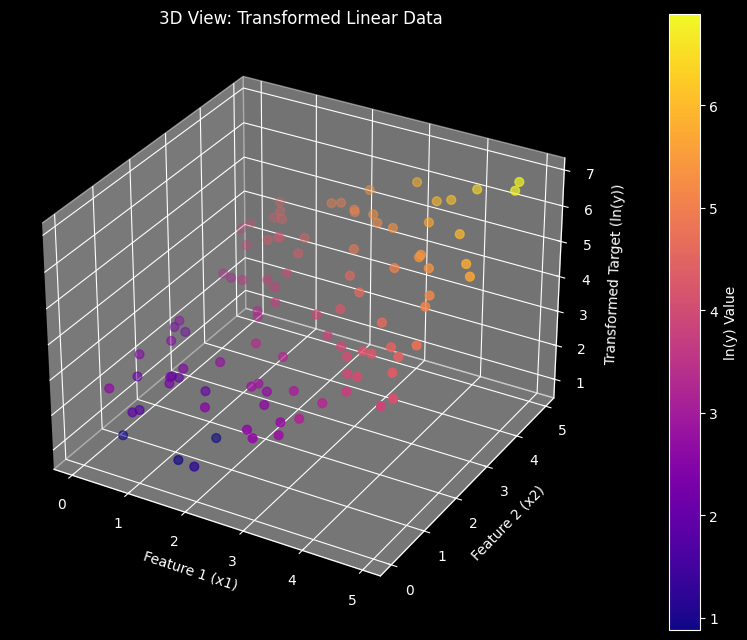

In [2]:
# ==========================================
# 3. DATA TRANSFORMATION & GRAPHING
# ==========================================

# Step 1: Filter out values <= 0 to avoid log math errors
valid_indices = y > 0
x1_clean = x1[valid_indices]
x2_clean = x2[valid_indices]
y_clean = y[valid_indices]

# Step 2: Transform target variable
y_transformed = np.log(y_clean)

# Step 3: Graph the transformed data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x1_clean, x2_clean, y_transformed, c=y_transformed, cmap='plasma', marker='o', s=40)

ax.set_xlabel('Feature 1 (x1)')
ax.set_ylabel('Feature 2 (x2)')
ax.set_zlabel('Transformed Target (ln(y))')
ax.set_title('3D View: Transformed Linear Data')
plt.colorbar(scatter, ax=ax, label='ln(y) Value', pad=0.1)
print("Transformation plot saved as '3d_transformed_data.png'")

# ==========================================
# 4. TRAINING THE MODEL
# ==========================================

# Format features and target for the custom model
# X must be an (N, 2) matrix. y must be an (N, 1) column vector.
X_train = np.column_stack((x1_clean, x2_clean))
y_train = y_transformed.reshape(-1, 1)

# Initialize model
model = LinearRegression(feat_len=2)

# Hyperparameters for gradient descent
learning_rate = 0.005
batch_size = 16
epochs = 200

# Fit the model using the generator
print("\nTraining Custom Linear Regression Model...")
generator = model.fit_generator(X_train, y_train, learning_rate, batch_size, epochs)

# Consume the generator to train the model to the final epoch
final_weights = None
for weights in generator:
    final_weights = weights

# Extract parameters
# final_weights shape is (1, 3). Indices: 0->x1 slope, 1->x2 slope, 2->intercept
recovered_B = final_weights[0, 0]
recovered_C = final_weights[0, 1]
intercept_beta = final_weights[0, 2]
recovered_A = np.exp(intercept_beta)

print("\n--- Parameter Recovery via Transformation & Custom Model ---")
print(f"Original A: 2.000  | Recovered A: {recovered_A:.3f}")
print(f"Original B: 0.600  | Recovered B: {recovered_B:.3f}")
print(f"Original C: 0.700  | Recovered C: {recovered_C:.3f}")
print(f"Final MSE: {model.calculate_mse(X_train, y_train):.4f}")

### Now we will try to fit an actual exponential curve

In [3]:
def exponential_surface(X, A, B, C):
    x1_val, x2_val = X
    return A * np.exp(B * x1_val + C * x2_val)

In [4]:
X_packed = (x1, x2)

initial_guesses = [1.0, 0.5, 0.5]

optimal_params, covariance = curve_fit(exponential_surface, X_packed, y, p0=initial_guesses)

recovered_A, recovered_B, recovered_C = optimal_params

print("--- Parameter Recovery via Direct Curve Fit ---")
print(f"Original A: 2.000  | Recovered A: {recovered_A:.3f}")
print(f"Original B: 0.600  | Recovered B: {recovered_B:.3f}")
print(f"Original C: 0.700  | Recovered C: {recovered_C:.3f}")
print(f"Final MSE: {model.calculate_mse(X_train, y_train):.4f}")

--- Parameter Recovery via Direct Curve Fit ---
Original A: 2.000  | Recovered A: 2.006
Original B: 0.600  | Recovered B: 0.594
Original C: 0.700  | Recovered C: 0.706
Final MSE: 0.1045


In [4]:
# to do: mixed relations for example e^x + ln(x)
# do some GAM (Generalized additive models)